In [63]:
from datamodel import OrderDepth, UserId, TradingState, Order
from typing import List, Dict
import string
import numpy as np

In [64]:
# DRYLAND FLAX
# setup data
# df_orders[price] = [bid_vol (buys), ask_vol (sells)]
df_orders: Dict[int, list(int)] = {
    27: [28_000, 0],
    28: [12_000, 40_000],
    29: [5_000, 0],
    30: [30_000, 0],
    31: [0, 20_000],
    32: [0, 20_000],
    33: [0, 30_000]
}


In [65]:


# if our bid is below min price??


def get_vol_traded(guess_price: int, orders: Dict[int, list(int)], user_price: int, user_is_bid: bool, user_qty: int ) -> int:
    bid_qty = 0
    ask_qty = 0
    for price, qtys in orders.items():
        if price >= guess_price:
            bid_qty += qtys[0]
        
        if price <= guess_price:
            ask_qty += qtys[1]

    if user_is_bid and user_price >= guess_price:
        bid_qty += user_qty
    elif (not user_is_bid) and user_price <= guess_price:
        ask_qty += user_qty

    clear_vol = min(bid_qty, ask_qty)

    return clear_vol

def get_clear_price(orders: Dict[int, list(int)], user_price: int, user_is_bid: bool, user_qty: int) -> int:
    min_price = min(orders)
    max_price = max(orders)
    
    max_vol = 0
    clear_price = 0

    for price in range(min_price, max_price+1):
        new_vol = get_vol_traded(price, orders, user_price, user_is_bid, user_qty)
        # i use >= in order to make sure we automatically break ties
        if new_vol >= max_vol:
            max_vol = new_vol
            clear_price = price

    # print(clear_price)
    return clear_price


In [66]:

def calc_pnl(orders: Dict[int, list(int)], user_price: int, user_is_bid: bool, user_qty: int, end_buy_price: int, fee_per_unit: float = 0.0):
    clear_price = get_clear_price(orders, user_price, user_is_bid, user_qty)
    
    # stale book qtys
    total_demand = 0
    total_supply = 0
    for price, qtys in orders.items():
        if price >= clear_price:
            total_demand += qtys[0]
        
        if price <= clear_price:
            total_supply += qtys[1]
            
    actual_qty = 0
    margin = 0
    

    if user_is_bid and user_price >= clear_price:
        # ALL demand ahead of you (you are last at your level)
        demand_ahead = sum(qtys[0] for p, qtys in orders.items() if p >= user_price)

        # what's left after they fill
        remaining_supply = max(0, total_supply - demand_ahead)

        actual_qty = min(user_qty, remaining_supply)
        margin = end_buy_price - clear_price

    elif (not user_is_bid) and user_price <= clear_price:
        # ALL supply ahead of you
        supply_ahead = sum(qtys[1] for p, qtys in orders.items() if p <= user_price)

        remaining_demand = max(0, total_demand - supply_ahead)

        actual_qty = min(user_qty, remaining_demand)
        margin = clear_price - end_buy_price

    pnl = actual_qty * margin
    pnl -= 2 * actual_qty * fee_per_unit
    return [pnl, clear_price]



In [67]:
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
import math

def plot_all(orders: Dict[int, list(int)], end_buy_price: int, fee_per_unit: float = 0.0, max_qty: int= 40_000):
    min_price = min(orders)
    max_price = max(orders)

    possible_prices = list(range(min_price, max_price + 1))
    possible_is_bid = [True, False]
    possible_qtys = range(0, max_qty + 1, 1000)

    num_plots = len(possible_prices) * len(possible_is_bid)
    cols = 4
    rows = math.ceil(num_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()

    plot_idx = 0

    for is_bid in possible_is_bid:
        side = "BID" if is_bid else "ASK"

        for price in possible_prices:
            pnls = []
            prices = []

            for qty in possible_qtys:
                pnl, clear_price = calc_pnl(df_orders, price, is_bid, qty, end_buy_price, fee_per_unit)
                pnls.append(pnl)
                prices.append(clear_price)

            ax = axes[plot_idx]
            # 1. Reshape coordinates into segments: (x0, y0) -> (x1, y1)
            points = np.array([possible_qtys, pnls]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            # 2. Create the LineCollection and map the 'prices' array to colors
            norm = plt.Normalize(min(prices), max(prices))
            lc = LineCollection(segments, cmap='viridis', norm=norm)
            lc.set_array(np.array(prices))
            lc.set_linewidth(2)

            # 3. Add to axes and set limits (LineCollection doesn't auto-scale axes)
            line = ax.add_collection(lc)
            ax.set_xlim(min(possible_qtys), max(possible_qtys))
            ax.set_ylim(min(pnls), max(pnls))

            # 4. Add the Colorbar
            cbar = fig.colorbar(line, ax=ax)
            cbar.set_label('Clearing Price')

            ax.set_title(f"{side} @ {price}")
            ax.set_xlabel("Qty")
            ax.set_ylabel("PnL")
            ax.grid()

            plot_idx += 1

    # Hide any unused subplots
    for i in range(plot_idx, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

/var/folders/2g/jt9wfv4179z71_g9wvbdtgn40000gn/T/ipykernel_66644/941825033.py:48: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(min(pnls), max(pnls))


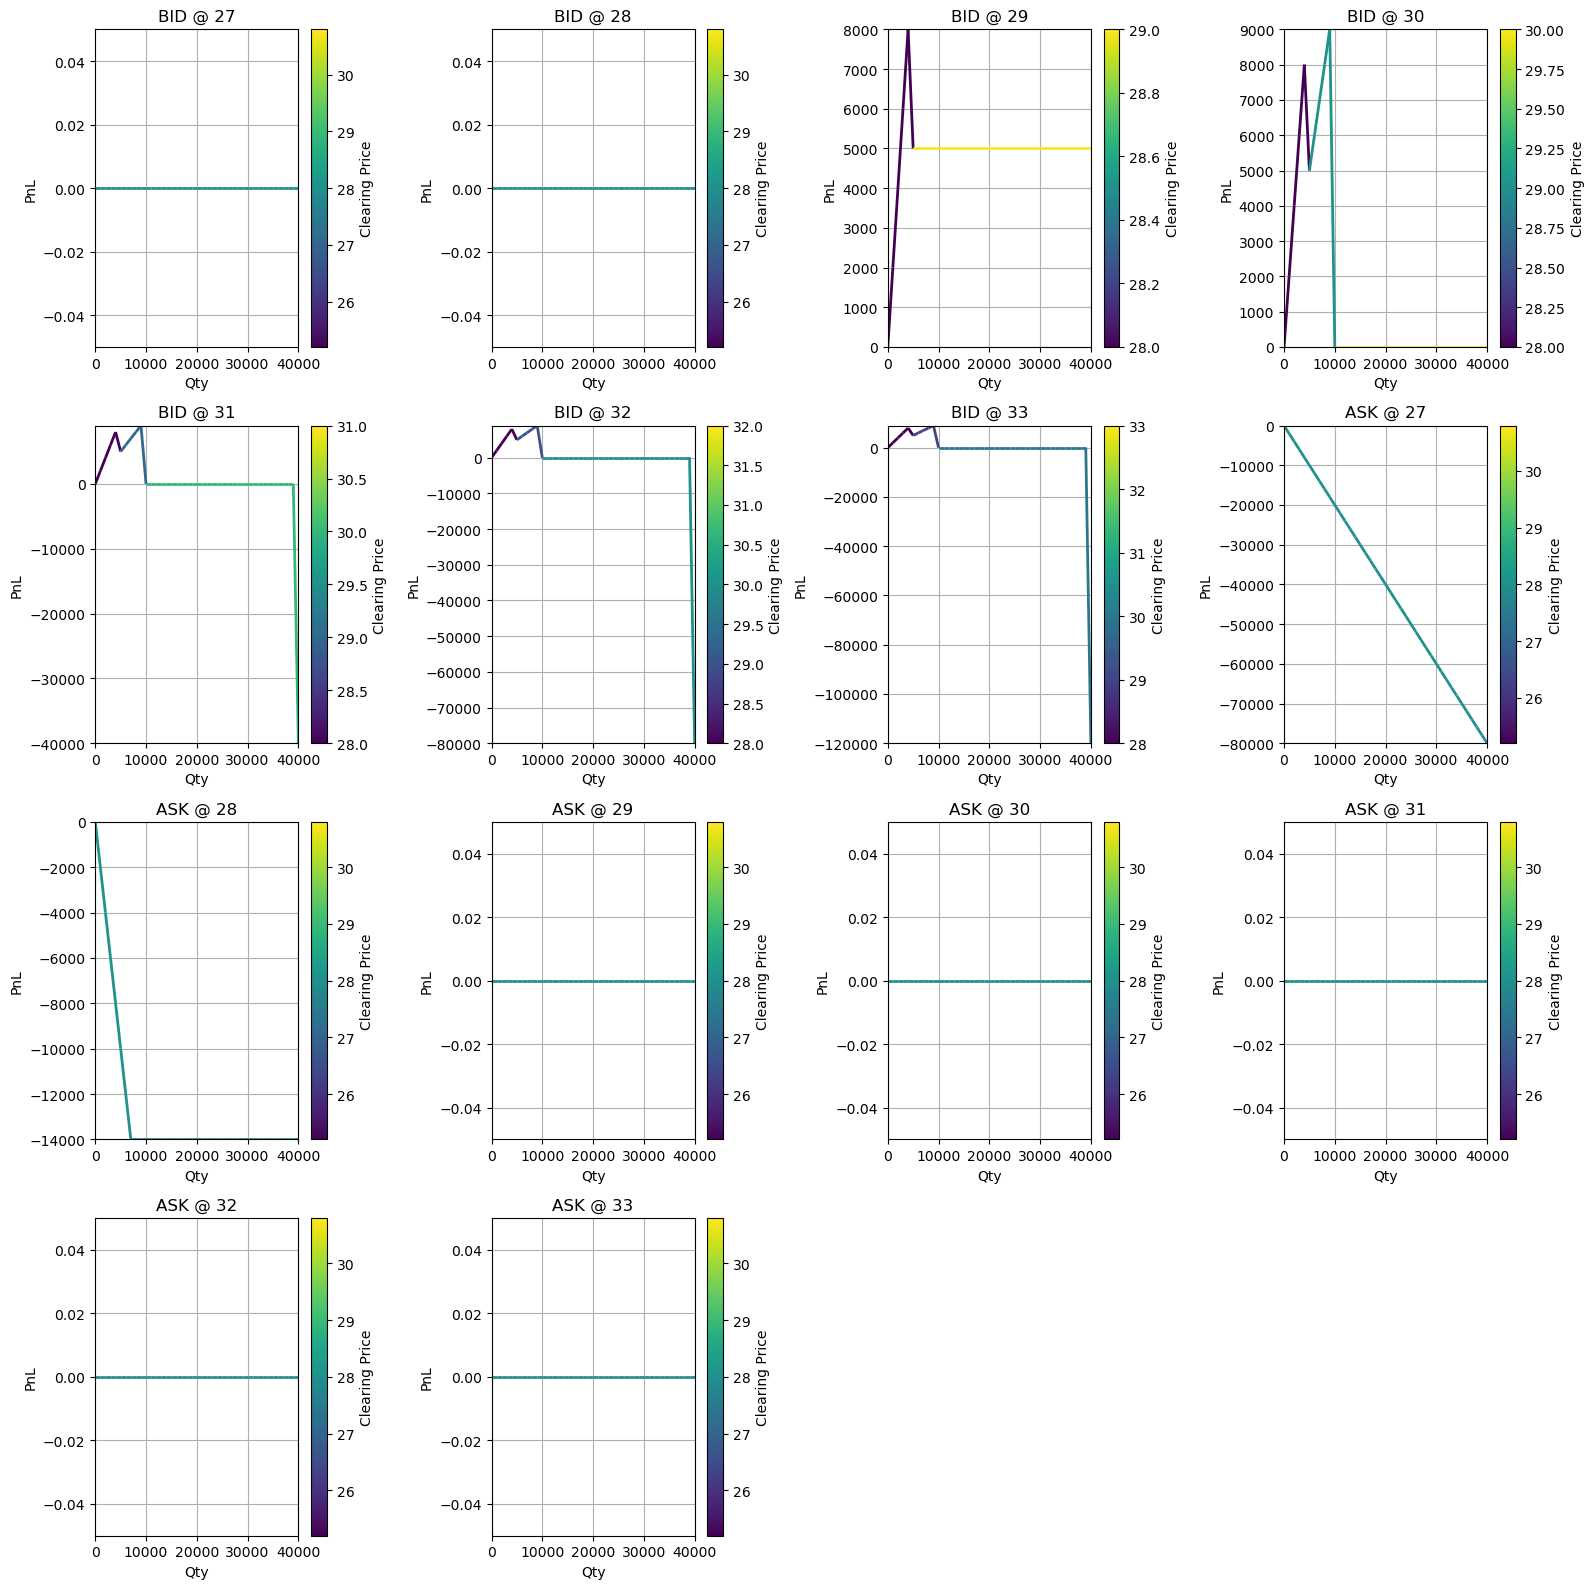

In [68]:
# plot all for dryland flax
plot_all(df_orders, 30)

/var/folders/2g/jt9wfv4179z71_g9wvbdtgn40000gn/T/ipykernel_66644/941825033.py:48: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(min(pnls), max(pnls))


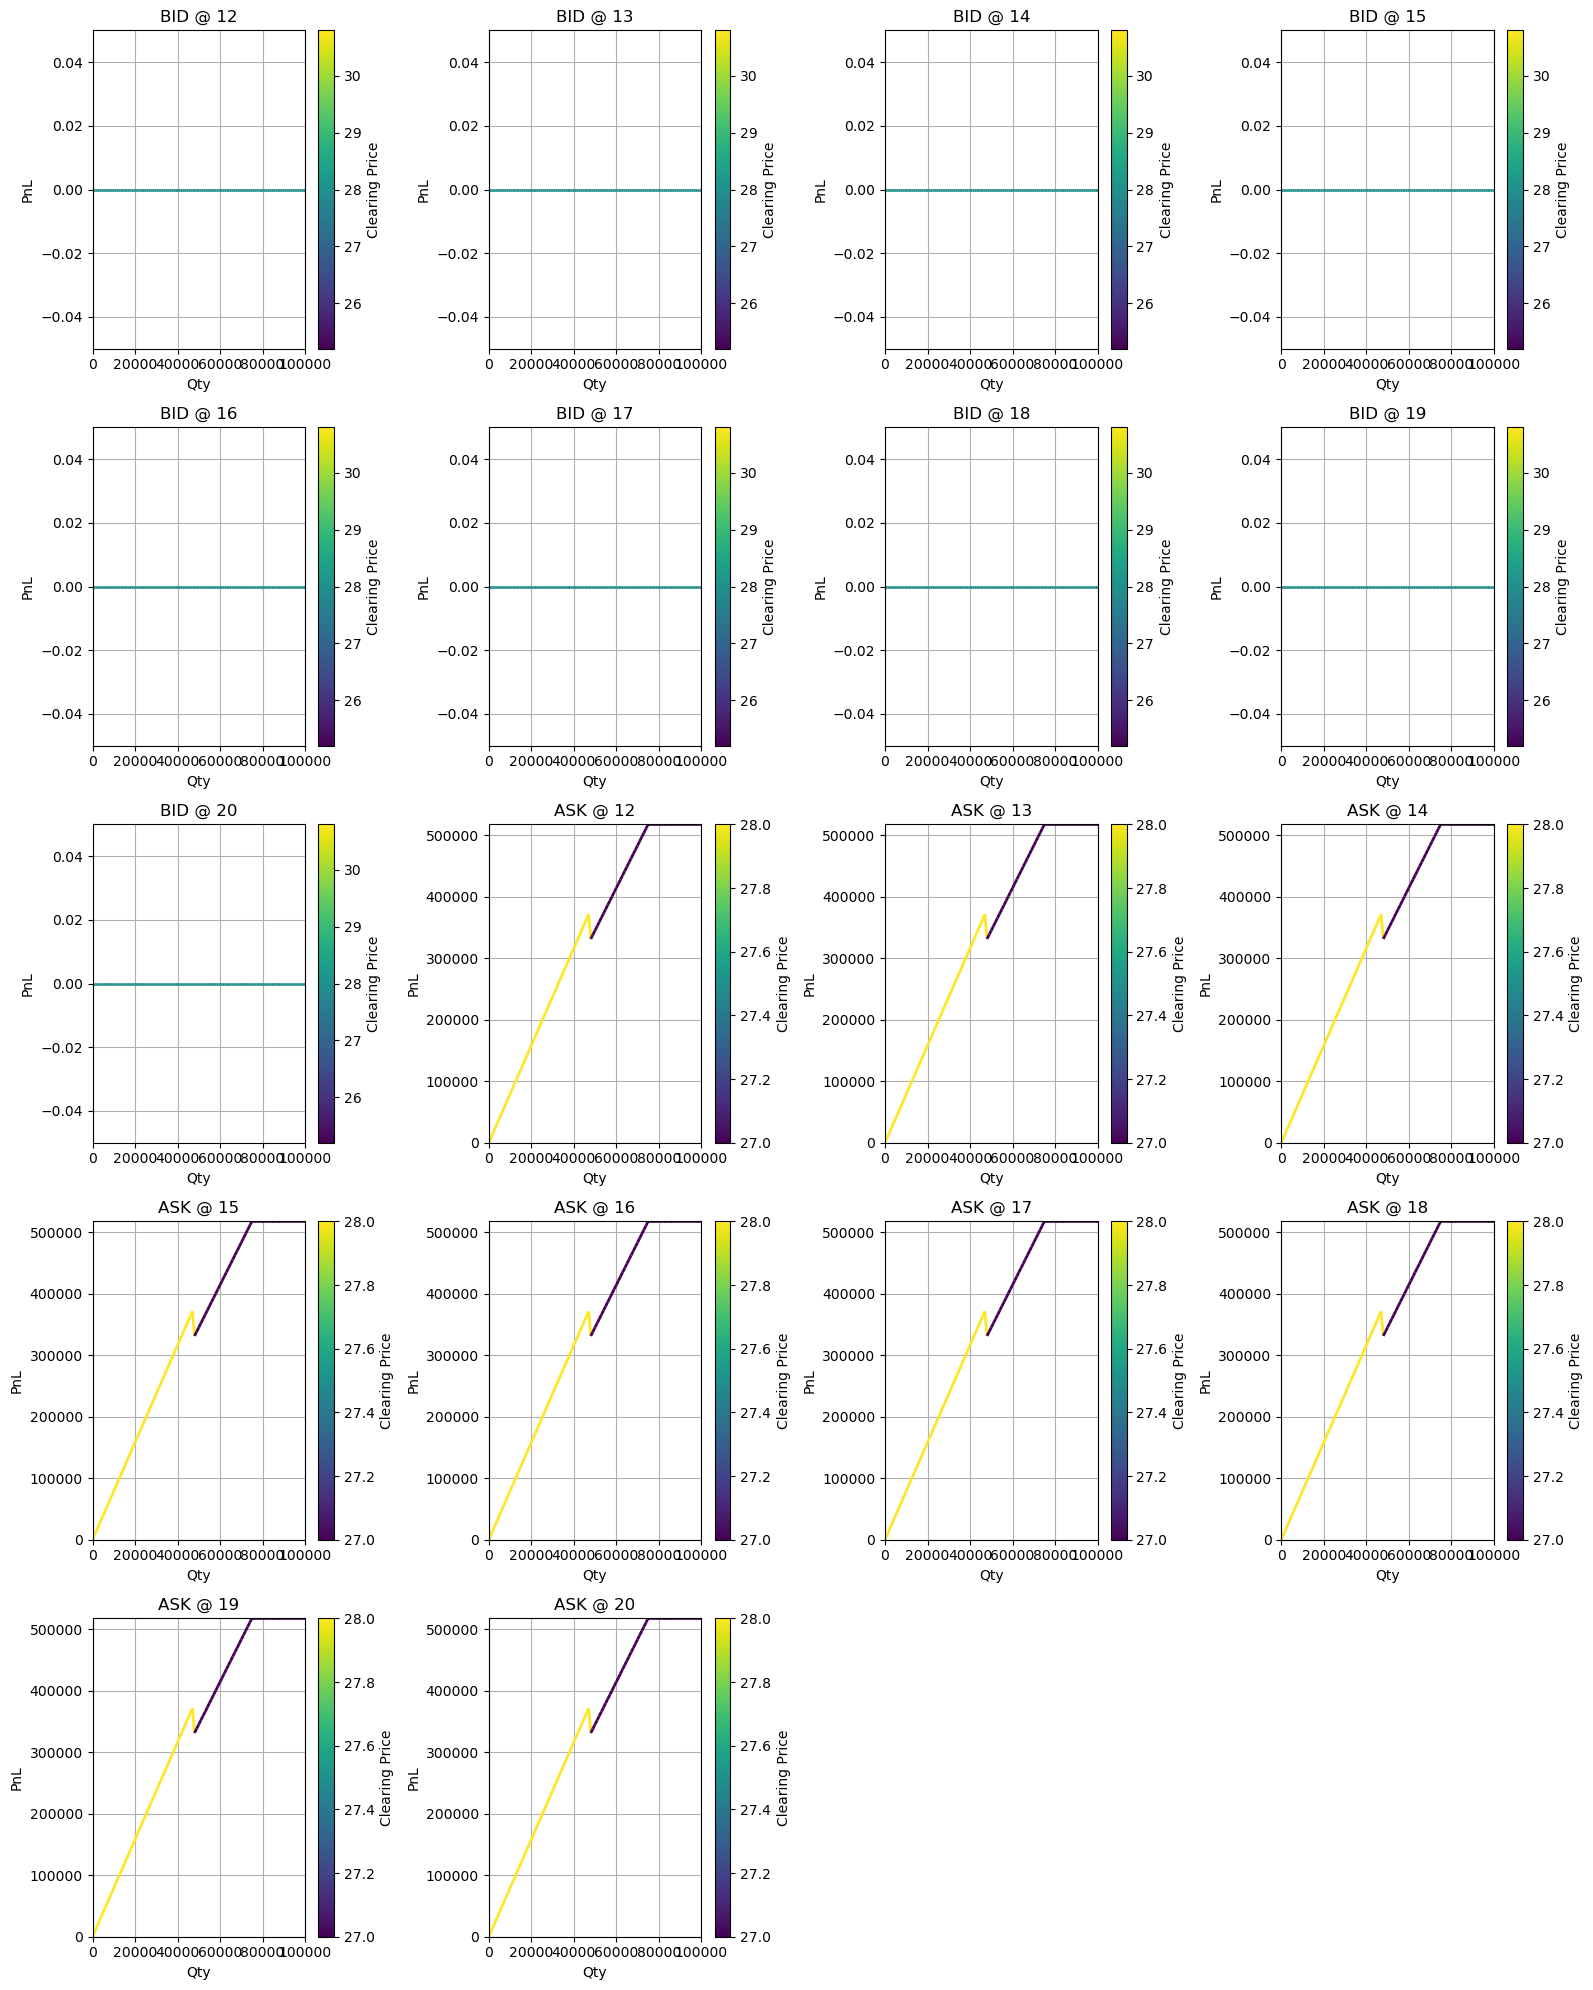

In [69]:
em_orders: Dict[int, list(int)] = {
    12: [0, 20_000],
    13: [7_000, 25_000],
    14: [10_000, 35_000],
    15: [5_000, 6_000],
    16: [10_000, 5_000],
    17: [5_000, 0],
    18: [6_000, 10_000],
    19: [17_000, 12_000],
    20: [43_000, 0]
}

# NOTE: FEE PER UNIT IS PER TRADE, SO IT'S DOUBLED IN CALCS
plot_all(em_orders, 20, 0.05, 100_000)
